# Set up imports

In [1]:
import json
import logging
import numpy as np
from blastwave import ZTFClient, LSSTClient, BOOMCredentialsError, BOOMQuery
from blastwave.models import Observation, Source
from blastwave.projections import lsst_aux_projection, ztf_aux_projection, ztf_alert_projection
from blastwave.utils import get_crossmatch_path, get_photometry_path, get_source_path
from astropy.time import Time
from babamul.models import LsstAlert, ZtfAlert
from pathlib import Path
from IPython.display import display

In [2]:
logger = logging.getLogger(__name__)

# Create ZTF Client

In [3]:
client = ZTFClient()

In [4]:
client.get_entry_count()

882418109

In [5]:
client.get_sample_data()

{'_id': 1356491846315015021,
 'objectId': 'ZTF20acayuvy',
 'candidate': {'jd': 2459110.9918403,
  'fid': 2,
  'pid': 1356491846315,
  'diffmaglim': 20.537776947021484,
  'programpi': 'Kulkarni',
  'programid': 1,
  'candid': 1356491846315015021,
  'isdiffpos': True,
  'nid': 1356,
  'rcid': 63,
  'field': 701,
  'ra': 60.0758851,
  'dec': 42.6743383,
  'magpsf': 19.10582160949707,
  'sigmapsf': 0.19582965970039368,
  'chipsf': 8.493492126464844,
  'magap': 19.595500946044922,
  'sigmagap': 0.179299995303154,
  'distnr': 0.5272969603538513,
  'magnr': 20.23699951171875,
  'sigmagnr': 0.03999999910593033,
  'chinr': 0.9490000009536743,
  'sharpnr': -0.04399999976158142,
  'sky': 0.33356019854545593,
  'fwhm': 1.5199999809265137,
  'classtar': 0.9990000128746033,
  'mindtoedge': 402.20050048828125,
  'seeratio': 1.5243061780929565,
  'aimage': 0.4749999940395355,
  'bimage': 0.3370000123977661,
  'elong': 1.4094955921173096,
  'nneg': 7,
  'nbad': 0,
  'rb': 0.42571428418159485,
  'ssdist

In [6]:
client.get_sample_data(catalog="ZTF_alerts_aux")

{'_id': 'ZTF18abjkxsl',
 'prv_candidates': [{'jd': 2458323.7942708,
   'fid': 2,
   'pid': 569294271315,
   'diffmaglim': 19.73487663269043,
   'programpi': 'Prince',
   'programid': 3,
   'candid': 569294271315010006,
   'isdiffpos': False,
   'nid': 569,
   'rcid': 13,
   'field': 683,
   'ra': 271.2442745,
   'dec': 31.2335389,
   'magpsf': 16.86673927307129,
   'sigmapsf': 0.16127020120620728,
   'chipsf': 637.8372192382812,
   'magap': 17.223600387573242,
   'sigmagap': 0.058400001376867294,
   'distnr': 3.7082815170288086,
   'magnr': 13.141999244689941,
   'sigmagnr': 0.017999999225139618,
   'chinr': 0.49399998784065247,
   'sharpnr': -0.035999998450279236,
   'sky': 0.17207729816436768,
   'fwhm': 2.3499999046325684,
   'mindtoedge': 330.2232971191406,
   'seeratio': 1.1041220426559448,
   'aimage': 1.3609999418258667,
   'bimage': 1.0410000085830688,
   'elong': 1.3073967695236206,
   'nneg': 7,
   'nbad': 0,
   'rb': 0.27000001072883606,
   'ssdistnr': -999.0,
   'ssmagnr': 

# Get latest entry

In [7]:
object_id = "ZTF26aaonmha"

In [8]:
s = client.get_source(object_id)

In [9]:
s.get_detections()

,jd,magpsf,sigmapsf,diffmaglim,ra,dec,snr,band,survey,det_type,isdiffpos,estdiffmaglim,mjd
0,2.461122e+06,19.904110,0.181700,19.607500,NaN,NaN,5.975425,r,ZTF,fp,True,20.097607,61121.300162
1,2.461122e+06,19.699455,0.175448,20.088846,149.928704,0.418445,6.188365,g,ZTF,alert,True,19.930970,61121.316262
2,2.461123e+06,18.892200,0.134397,20.445000,149.928636,0.418461,8.078574,r,ZTF,alert,True,19.413112,61122.225498
3,2.461123e+06,18.851482,0.085999,20.467262,149.928651,0.418446,12.624923,r,ZTF,alert,True,19.857129,61122.225972
4,2.461126e+06,17.614571,0.049017,19.955912,149.928675,0.418446,22.150185,r,ZTF,alert,True,19.230589,61125.211262
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,2.461205e+06,19.198166,0.006874,22.947083,149.928634,0.418430,157.183411,i,LSST,alert,True,22.941758,61204.972961
97,2.461205e+06,22.156906,0.133998,22.681047,149.928614,0.418424,8.088040,u,LSST,alert,True,22.679089,61204.976821
98,2.461205e+06,19.807106,0.009866,23.163658,149.928625,0.418447,109.005089,g,LSST,alert,True,23.153298,61204.981323
99,2.461206e+06,19.118095,0.156567,19.592087,149.928721,0.418476,6.934622,r,ZTF,alert,True,19.473227,61205.181088


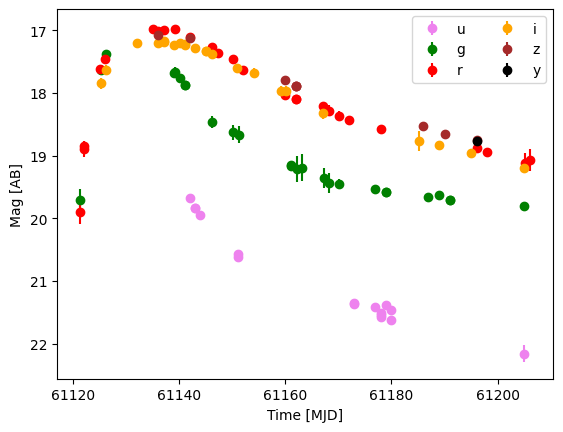

In [10]:
s.show_lightcurve()

Using LSST id 314003014107006318


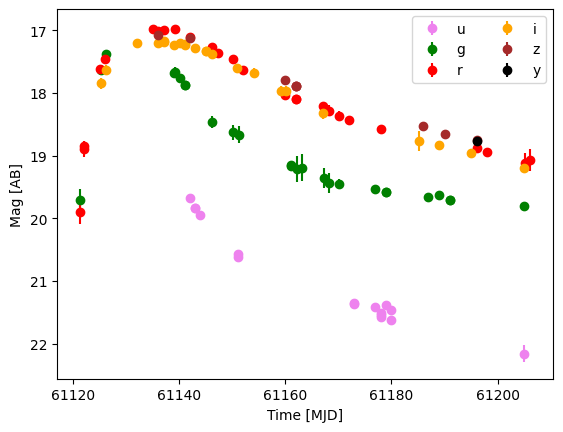

In [11]:
# We can get exactly the same data by querying via the LSST ID
print(f"Using LSST id {s.lsstid}")
s = client.get_source(s.lsstid, catalog="LSST_alerts")
s.show_lightcurve()

In [12]:
s.get_crossmatches()

{'NED': [{'_id': 'SDSS J095942.88+002506.2',
   'ra': 149.9286669858,
   'dec': 0.4183989906,
   'objtype': 'G',
   'z': 0.03451399877667427,
   'z_unc': 0.0002969999914057553,
   'z_tech': 'SPEC',
   'z_qual': False,
   'z_refcode': '20012dF...C...0000C',
   'ebv': 0.02097306214272976,
   'ml_ratio': 0.5,
   'distance_arcsec': 0.22815217096836274}],
 '2MASS_PSC': [],
 'GALEX': [],
 'VSX': [],
 'LSPSC': [{'_id': 10995466341720757,
   'ra': 149.92868041992188,
   'dec': 0.41843000054359436,
   'mag_white': 18.989999771118164,
   'score': 0.004000000189989805,
   'distance_arcsec': 0.20699747518869194}],
 'milliquas_v8': [],
 'TNS': [],
 'Gaia_DR3': [{'_id': 3833530685621513728,
   'ra': 149.92868041992188,
   'dec': 0.4184304177761078,
   'parallax': None,
   'parallax_error': None,
   'pm': None,
   'pmra': None,
   'pmra_error': None,
   'pmdec': None,
   'pmdec_error': None,
   'phot_g_mean_mag': 21.04098892211914,
   'phot_bp_mean_mag': 19.99397087097168,
   'phot_rp_mean_mag': 19.5

# Query by date

In [13]:
datestr = "20260603"

t_now = Time(datestr[:4] + "-" + datestr[4:6] + '-' + datestr[6:] + 'T15:00:00.0',
            format='isot').jd

if t_now < 2458653.5:  # 2019-06-19
    logger.warning("Using old  data query settings, before drb was introduced.")
    # there is no drb for early data (from an old email: before June 19 2019)
    rb_cut = {'candidate.rb': {'$gt': 0.5}}
else:
    # Anna's suggestion. That gives a 1.7% FNR and FPR.
    rb_cut = {'candidate.drb': {'$gt': 0.65}}

new_cuts = {
    "$and": [
        # not star
        {"$or": [
            {"candidate.sgscore1": {"$lt": 0.51}},
            {"candidate.distpsnr1": {"$gt": 3.0}}
        ]},
        # Not |b| < 10
        {"$or": [
            {"coordinates.b": {"$gt": 10}},
            {"coordinates.b": {"$lt": -10}},
        ]},
        # Not near bright gaia star
        {"$or": [
            {"candidate.neargaiabright": {"$gt": 5}},
            {"candidate.neargaiabright": {"$lt": -0}}
        ]},
    ],
    # nuclear
    "candidate.distpsnr1": {"$lt": 0.9},
    # "properties.rock": {'$eq': False},
    # "properties.star": {'$eq': False},
    # 'properties.near_brightstar': {'$eq': False},
    # "properties.stationary": {'$eq': True},

}

# gt is greater than, lt is lower than
mongodb_filter = {
    'candidate.jd': {
        # '$gt': t_now - 10.,
        '$gt': t_now - 1.0,
        '$lt': t_now
    },
    'candidate.isdiffpos': {'$eq': True},
    'candidate.programid': {'$gt': 0},
    'candidate.ssdistnr': {'$lt': -1},
    **rb_cut,
    **new_cuts
}

query = {
    "catalog_name": client.catalog,
    "filter": mongodb_filter,
    "projection": {"objectId": 1},
    "limit": None,
    "max_time_ms": None,
}
query

{'catalog_name': 'ZTF_alerts',
 'filter': {'candidate.jd': {'$gt': np.float64(2461194.125),
   '$lt': np.float64(2461195.125)},
  'candidate.isdiffpos': {'$eq': True},
  'candidate.programid': {'$gt': 0},
  'candidate.ssdistnr': {'$lt': -1},
  'candidate.drb': {'$gt': 0.65},
  '$and': [{'$or': [{'candidate.sgscore1': {'$lt': 0.51}},
     {'candidate.distpsnr1': {'$gt': 3.0}}]},
   {'$or': [{'coordinates.b': {'$gt': 10}}, {'coordinates.b': {'$lt': -10}}]},
   {'$or': [{'candidate.neargaiabright': {'$gt': 5}},
     {'candidate.neargaiabright': {'$lt': 0}}]}],
  'candidate.distpsnr1': {'$lt': 0.9}},
 'projection': {'objectId': 1},
 'limit': None,
 'max_time_ms': None}

In [14]:
client.count(query)

3372

In [15]:
res = client.query(query)

In [16]:
res[0]

{'_id': 3440490595115015001, 'objectId': 'ZTF17aaaewpo'}

In [17]:
object_ids = [x["objectId"] for x in res]
len(object_ids)

3372

In [18]:
object_ids = list(set(object_ids))
len(object_ids)

2399